In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / "evaluation" / "compilation-plan" / "solver.py").exists():
            return path
    raise RuntimeError("Could not find the truejit repository root")


PROJECT_ROOT = find_project_root(Path.cwd())
EVAL_DIR = PROJECT_ROOT / "evaluation" / "compilation-plan"
if str(EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_DIR))

OUT_DIR = EVAL_DIR / "out"


In [3]:
import benchmarks as B

PROFILE_CSV = "profile.csv"


def _profiles_dir(binary, workload_name=None, mode=None):
    root = Path(str(binary).replace('/benchmarks/', '/profiles/')).parent
    if workload_name is not None:
        root = root / workload_name
    if mode is not None:
        root = root / mode
    return root


def has_mode_data(binary, workload_name, mode):
    d = _profiles_dir(binary, workload_name, mode)
    return d.exists() and any(p.is_dir() for p in d.iterdir())


def workloads_with_profile(benchmark):
    return [
        wl for wl in benchmark.workloads
        if (_profiles_dir(benchmark.binary, wl.name) / PROFILE_CSV).exists()
    ]


_seen = set()
CANDIDATE_BENCHMARKS = []
for _b in B.all_benchmarks:
    _key = frozenset((str(_b.binary), wl.name) for wl in _b.workloads)
    if _key not in _seen:
        _seen.add(_key)
        CANDIDATE_BENCHMARKS.append(_b)

AVAILABLE_BENCHMARKS = [
    b for b in CANDIDATE_BENCHMARKS
    if b.binary.exists()
    and (_profiles_dir(b.binary) / 'metadata.csv').exists()
    and any(
        has_mode_data(b.binary, wl.name, 'jit') or has_mode_data(b.binary, wl.name, 'interp')
        for wl in b.workloads
    )
]
print(f"{len(AVAILABLE_BENCHMARKS)} benchmarks available")


70 benchmarks available


In [4]:
from contextlib import redirect_stdout
from io import StringIO

from profiling import get_static_info, get_history
from solver import Constraint, EndToEndTime, ObjectiveFunction, PlanEvaluation, Planner

SWEEP_POINTS      = 12
MAX_BUDGET_BYTES  = None
RECOMPUTE_RESULTS = False
DEFAULT_MODE      = "interpret"


class EvaluatedCodeSize(ObjectiveFunction):
    priorities = ["interpret", "async", "jit", "specialize", "static"]

    def __init__(self):
        super().__init__()
        self.calculator = {
            "interpret":  lambda fn: 0,
            "jit":        lambda fn: self.profile.loc[fn, "size.dynamic.jit"],
            "async":      lambda fn: self.profile.loc[fn, "size.dynamic.jit"],
            "specialize": lambda fn: self.profile.loc[fn, "size.dynamic.spec"],
            "static":     lambda fn: self.profile.loc[fn, "size.static"] + self.profile.loc[fn, "size.dynamic.jit"],
        }


def load_profile(path):
    df = pd.read_csv(path)
    for col in ["exec.jit", "exec.interp", "freq.jit", "freq.interp"]:
        other = col.replace(".jit", ".interp") if ".jit" in col else col.replace(".interp", ".jit")
        df[col] = df[col].fillna(df[other])
    df["compilation.jit"]  = df["compilation.jit"].fillna(0)
    df["start.jit"]        = df["start.jit"].fillna(0)
    df["start.interp"]     = df["start.interp"].fillna(0)
    df["size.dynamic.jit"] = df["size.dynamic.jit"].fillna(0)
    df["size.static"]      = df["size.static"].fillna(0)
    return df


def workload_code_size(profile):
    return int((profile["size.static"].fillna(0) + profile["size.dynamic.jit"].fillna(0)).sum())


def make_budget_sweep(max_code_size, points=12):
    if max_code_size <= 0:
        return np.array([0], dtype=int)
    smallest = max(1, int(max_code_size * 0.0001))
    geometric = np.geomspace(smallest, max_code_size, points)
    anchors = np.array([0, 4*1024, 16*1024, 64*1024, 256*1024, 1*1024*1024, max_code_size])
    budgets = np.unique(np.concatenate([geometric, anchors]).round().astype(int))
    return budgets[(budgets >= 0) & (budgets <= max_code_size)]


def _evaluate_plan(wl_name, plan, budget, label, *, static_info, wl_profiles, wl_histories):
    ev = PlanEvaluation(static_info, wl_profiles[wl_name], plan, wl_histories[wl_name])
    return {
        "workload": wl_name, "label": label, "budget": budget,
        "code_size": int(ev.static_code_size + ev.dynamic_code_size),
        "e2e": int(ev.e2e), "exec": int(ev.exec), "waiting": int(ev.waiting),
        "compilation": int(ev.compilation), "interpret": int(ev.interpret),
        "jit": int(ev.jit), "async": int(ev.async_compilation),
        "specialize": int(ev.specialize), "static": int(ev.static),
    }


def _solve_workload(wl_name, *, static_info, wl_profiles, wl_histories):
    profile  = wl_profiles[wl_name]
    max_size = int(MAX_BUDGET_BYTES or workload_code_size(profile))
    rows = []
    for budget in make_budget_sweep(max_size, SWEEP_POINTS):
        planner = Planner(EndToEndTime(),
                          [Constraint(EvaluatedCodeSize(), upper_bound=int(budget))],
                          DEFAULT_MODE)
        with redirect_stdout(StringIO()):
            plan = planner.plan(static_info, profile)
        rows.append(_evaluate_plan(wl_name, plan, int(budget), "sweep",
                                   static_info=static_info, wl_profiles=wl_profiles,
                                   wl_histories=wl_histories))
    for mode in ["interpret", "jit", "static"]:
        with redirect_stdout(StringIO()):
            plan = Planner(None, None, mode).plan(static_info, profile)
        rows.append(_evaluate_plan(wl_name, plan, None, mode,
                                   static_info=static_info, wl_profiles=wl_profiles,
                                   wl_histories=wl_histories))
    with redirect_stdout(StringIO()):
        plan = Planner(EndToEndTime(), [], DEFAULT_MODE).plan(static_info, profile)
    rows.append(_evaluate_plan(wl_name, plan, None, "unbounded min-E2E",
                               static_info=static_info, wl_profiles=wl_profiles,
                               wl_histories=wl_histories))
    return rows


for _benchmark in AVAILABLE_BENCHMARKS:
    _csv = OUT_DIR / f"pareto-curve.{_benchmark.name.lower()}-all-workloads.csv"
    if _csv.exists() and not RECOMPUTE_RESULTS:
        continue
    _workloads = workloads_with_profile(_benchmark)
    if not _workloads:
        continue
    print(f"[{_benchmark.name}] solving {len(_workloads)} workload(s)...")
    _static_info  = get_static_info(_benchmark.binary)
    _wl_profiles  = {wl.name: load_profile(_profiles_dir(_benchmark.binary, wl.name) / PROFILE_CSV)
                     for wl in _workloads}
    _wl_histories = {wl.name: get_history(_benchmark.binary, wl.name, "jit")
                     for wl in _workloads}
    _rows = []
    for _i, _wl in enumerate(_workloads, 1):
        print(f"  [{_i}/{len(_workloads)}] {_wl.name}")
        _rows.extend(_solve_workload(_wl.name, static_info=_static_info,
                                     wl_profiles=_wl_profiles, wl_histories=_wl_histories))
    pd.DataFrame(_rows).to_csv(_csv, index=False)
    print(f"  saved {_csv.name}")

print("CSV cache ready.")


CSV cache ready.


In [5]:
all_results = {}
for benchmark in AVAILABLE_BENCHMARKS:
    results_csv = OUT_DIR / f"pareto-curve.{benchmark.name.lower()}-all-workloads.csv"
    if not results_csv.exists():
        print(f"[{benchmark.name}] no cached results — skipping")
        continue
    results = pd.read_csv(results_csv)
    results["code_size_mb"] = results["code_size"] / 1e6
    results["e2e_s"]        = results["e2e"] / 1e9
    results["budget_mb"]    = results["budget"] / 1e6
    all_results[benchmark.name] = results

AVAILABLE_BENCHMARKS = [b for b in AVAILABLE_BENCHMARKS if b.name in all_results]
print(f"{len(AVAILABLE_BENCHMARKS)} benchmarks with cached results loaded")


70 benchmarks with cached results loaded


In [6]:
import glob
import matplotlib.font_manager as fm

# Register Latin Modern Roman (the direct successor to Computer Modern / CMU).
for _f in glob.glob("/usr/share/texmf/fonts/opentype/public/lm/lmroman*"):
    fm.fontManager.addfont(_f)

# Register CMU (Computer Modern Unicode) fonts if available
for _f in glob.glob("/usr/share/texmf/fonts/opentype/public/cm-unicode/*"):
    fm.fontManager.addfont(_f)
for _f in glob.glob("/usr/share/fonts/truetype/cmu/*"):
    fm.fontManager.addfont(_f)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
})

baseline_styles = {
    "interpret":         ("#D55E00", "X", 100),
    "jit":               ("#56B4E9", "X", 100),
    "static":            ("#009E73", "X", 100),
}

legend_handles = [
    Line2D([0], [0], marker="X", linestyle="none", markerfacecolor="#D55E00", markeredgecolor="black", markersize=10, label="Interpreter", markeredgewidth=0.2),
    Line2D([0], [0], marker="X", linestyle="none", markerfacecolor="#56B4E9", markeredgecolor="black", markersize=10, label="JIT", markeredgewidth=0.2),
    Line2D([0], [0], marker="X", linestyle="none", markerfacecolor="#009E73", markeredgecolor="black", markersize=10, label="AOT", markeredgewidth=0.2),
    Line2D([0], [0], marker="o", linestyle="none", color="#7A5195", markersize=5, label="CAPER"),
]

NS   = 1e9


saved: evaluation/compilation-plan/out/pareto-curve.key-results.pdf


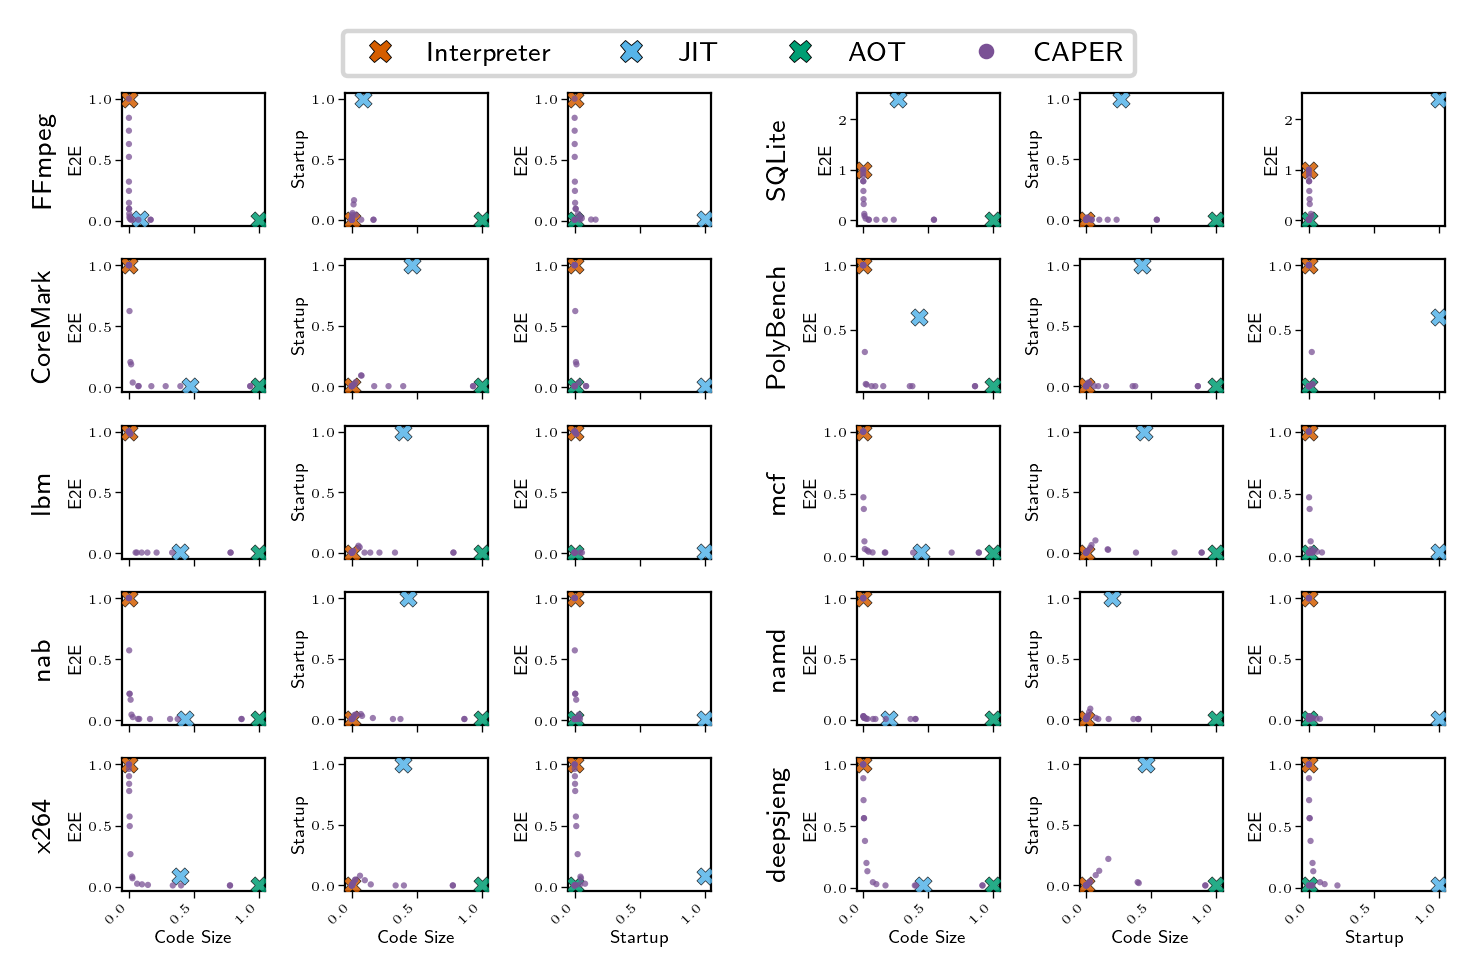

In [9]:
import math
from matplotlib.gridspec import GridSpec

def _select_workloads(benchmark):
    wls = workloads_with_profile(benchmark)
    if benchmark.name == "FFmpeg":
        return wls[:1]
    if benchmark.name == "SQLite":
        return wls[:1]
    if benchmark.name == "CoreMark":
        return wls
    if benchmark.suite == "SPEC":
        return wls
    if benchmark.suite == "PolyBench" and benchmark.name == "gemm":
        return wls
    return []

def _row_label(benchmark):
    if benchmark.suite == "PolyBench":
        return "PolyBench"
    return benchmark.name

all_wl_pairs_3dim = [
    (benchmark, wl)
    for benchmark in AVAILABLE_BENCHMARKS
    for wl in _select_workloads(benchmark)
]

dims3 = [
    ("code_size_mb", "e2e_s",     "Code Size", "E2E"),
    ("code_size_mb", "waiting_s", "Code Size", "Startup"),
    ("waiting_s",    "e2e_s",     "Startup",   "E2E"),
]


if not all_wl_pairs_3dim:
    raise RuntimeError("all_wl_pairs_3dim is empty — check filter in _select_workloads")

n_benchmarks = len(all_wl_pairs_3dim)
nrows_plot   = math.ceil(n_benchmarks / 2)

AXIS_LABEL_FONTSIZE = 4
TICK_LABEL_FONTSIZE = 3

# 7 GridSpec columns: [0,1,2] left group | [3] narrow spacer | [4,5,6] right group
fig = plt.figure(figsize=(4.5, 0.55 * nrows_plot), dpi=320, layout="constrained")
gs  = GridSpec(nrows_plot, 7, figure=fig,
               width_ratios=[1, 1, 1, 0.2, 1, 1, 1])

COL_MAP = [0, 1, 2, 4, 5, 6]  # skip spacer at index 3

axes = {}
for r in range(nrows_plot):
    for c in COL_MAP:
        axes[(r, c)] = fig.add_subplot(gs[r, c])

for bench_i, (benchmark, wl) in enumerate(all_wl_pairs_3dim):
    plot_row   = bench_i // 2
    col_offset = (bench_i % 2) * 3

    results   = all_results[benchmark.name]
    wl_data   = results[results["workload"] == wl.name].copy()
    sweep     = wl_data[wl_data["label"] == "sweep"].copy()
    baselines = wl_data[wl_data["label"] != "sweep"].copy()

    sweep["waiting_s"]     = sweep["waiting"] / NS
    baselines["waiting_s"] = baselines["waiting"] / NS

    # Per-workload normalization references
    _aot_row    = baselines[baselines["label"] == "static"]
    _interp_row = baselines[baselines["label"] == "interpret"]
    _jit_row    = baselines[baselines["label"] == "jit"]
    aot_code_size = _aot_row["code_size_mb"].values[0]  if len(_aot_row)    else 1.0
    interp_e2e    = _interp_row["e2e_s"].values[0]      if len(_interp_row) else 1.0
    jit_latency   = _jit_row["waiting_s"].values[0]     if len(_jit_row)    else 1.0
    if aot_code_size == 0: aot_code_size = 1.0
    if interp_e2e    == 0: interp_e2e    = 1.0
    if jit_latency   == 0: jit_latency   = 1.0

    for col_i, (x_col, y_col, x_lbl, y_lbl) in enumerate(dims3):
        ax = axes[(plot_row, COL_MAP[col_offset + col_i])]

        if col_i == 0:
            x_scale, y_scale = 1.0 / aot_code_size, 1.0 / interp_e2e
        elif col_i == 1:
            x_scale, y_scale = 1.0 / aot_code_size, 1.0 / jit_latency
        elif col_i == 2:
            x_scale, y_scale = 1.0 / jit_latency, 1.0 / interp_e2e

        unbounded = baselines[baselines["label"] == "unbounded min-E2E"]
        other_bl  = baselines[baselines["label"] != "unbounded min-E2E"]

        caper_x = pd.concat([sweep[x_col], unbounded[x_col]]) * x_scale
        caper_y = pd.concat([sweep[y_col], unbounded[y_col]]) * y_scale
        ax.scatter(caper_x, caper_y,
                   s=2, color="#7A5195", edgecolor="none", alpha=0.75, zorder=10)

        for _, row in other_bl.iterrows():
            color, marker, size = baseline_styles[row["label"]]
            ax.scatter(row[x_col] * x_scale, row[y_col] * y_scale,
                       s=size * 0.15, color=color, marker=marker,
                       edgecolor="black", linewidth=0.15, alpha=0.85, zorder=4)

        ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE, pad=0.5, length=1.5, width=0.3)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

        ax.set_ylabel(y_lbl, fontsize=AXIS_LABEL_FONTSIZE, labelpad=1)

        if plot_row == nrows_plot - 1:
            ax.set_xlabel(x_lbl, fontsize=AXIS_LABEL_FONTSIZE, labelpad=1)
            plt.setp(ax.get_xticklabels(), fontsize=TICK_LABEL_FONTSIZE, rotation=45, ha="right")
        else:
            ax.tick_params(axis="x", labelbottom=False)

    axes[(plot_row, COL_MAP[col_offset])].annotate(
        _row_label(benchmark),
        xy=(-0.55, 0.5), xycoords="axes fraction",
        fontsize=6, ha="center", va="center",
        rotation=90, annotation_clip=False,
    )

# Enforce consistent axis label fontsize for all axes
for ax in axes.values():
    ax.xaxis.label.set_fontsize(AXIS_LABEL_FONTSIZE)
    ax.yaxis.label.set_fontsize(AXIS_LABEL_FONTSIZE)

# Hide unused axes when n_benchmarks is odd
if n_benchmarks % 2 == 1:
    for logical_col in range(3, 6):
        axes[(nrows_plot - 1, COL_MAP[logical_col])].set_visible(False)

fig.legend(handles=legend_handles, loc="upper center", ncols=4,
           fontsize=6, markerscale=0.5, bbox_to_anchor=(0.5, 1.07),
              frameon=True,
           )

plot_pdf = OUT_DIR / "pareto-curve.key-results.pdf"
fig.savefig(plot_pdf, bbox_inches="tight", pad_inches=0.02, dpi=320)
print(f"saved: {plot_pdf.relative_to(PROJECT_ROOT)}")
plt.show()
